# Head Ablation — MLP vs Linear Probe

Determines whether the MLP projection head `Linear(512→128) → ReLU → Dropout(0.3) → Linear(128→1)` outperforms a minimal linear probe `Linear(512→1)` on the baseline ResNet18. This directly answers the examiner question: *are performance gains from the backbone or the head?*

**Design rationale:** the linear probe is strictly less expressive — it collapses the 512-dim embedding to a single logit with no intermediate representation. If the MLP wins, the projection layer adds value. If the linear probe matches it, all useful structure is already in the backbone features and the MLP's parameters are wasted capacity. The result fixes the head type for all subsequent architecture evaluation runs.

**Dropout note:** Dropout(0.3) in the MLP head is held fixed and not searched. Weight decay (1e-4, from grid search) already handles backbone regularisation; varying dropout would conflate two regularisation axes and make the head comparison uninterpretable.

**Protocol:**
- Both heads trained under `BEST_CONFIG` from the grid search: `lr_phase2=1e-4, weight_decay=1e-4`
- 5-fold stratified CV (increased from 3 used in grid search — more reliable estimate for a binary architectural choice)
- 2 head types × 5 folds = 10 runs total
- Results saved fold-by-fold to `head_ablation_results.csv`; safe to interrupt and resume
- **Selection criterion:** highest mean val F1 (primary — dataset is imbalanced). Ties: highest mean val acc, then lowest mean val loss.

## 1 - Paths & Imports

In [1]:
import sys
from pathlib import Path


ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT  = ABSOLUTE_PATH.parents[1]
DATA_DIR      = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR   = PROJECT_ROOT / "data" / "experiments" / "head-ablation-results"

GRID_SEARCH_RESULTS_DIR = PROJECT_ROOT / "data" / "experiments" / "grid-search-results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Results dir  : {RESULTS_DIR}")

Project root : C:\Users\markm\Workspace\ms-machine-learning-diagnosis
Data dir     : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
Results dir  : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\head-ablation-results


In [2]:
import csv
import traceback
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import f1_score

import src.scripts.data    as data
import src.scripts.models  as models
import src.scripts.trainer as trainer
import src.scripts.utils   as utils

utils.set_seed(42)

Random seed set to 42 for Python, NumPy, and PyTorch


## 2 - Data Preparation

The 80/20 stratified outer split uses the same seed (42) as every other notebook. The ablation operates exclusively within `X_trainval / y_trainval`; the held-out test set is untouched.

In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories, visualise=False)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

X_trainval, y_trainval, X_test, y_test = data.get_trainval_test_split(
    image_paths, labels,
    test_split=0.20,
    SEED=42
)

print(f"\nAblation operates on {len(X_trainval)} train+val samples.")
print("Held-out test set is NOT used at any point in this notebook.")

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_paths_and_labels()>>> Total images: 1652
get_trainval_test_split()>>> Train+Val pool : 1321 (80.0%)
get_trainval_test_split()>>> Held-out test  : 331 (20.0%)
get_trainval_test_split()>>> TrainVal class ratio — MS: 520  Non-MS: 801
get_trainval_test_split()>>> Test     class ratio — MS: 130  Non-MS: 201

Ablation operates on 1321 train+val samples.
Held-out test set is NOT used at any point in this notebook.


## 3 - Configuration

`BEST_LR_PHASE2` and `WD_PHASE1` are loaded directly from `grid-search-results/optimal_config.csv` produced by the grid search notebook. If the file is missing, the cell raises a `FileNotFoundError` with instructions — run the grid search first.

All other training parameters (epochs, patience, batch size) are fixed here and not searched.

In [6]:
# ── Load best config from grid search optimal_config.csv ─────────────────
OPTIMAL_CONFIG_FILE = GRID_SEARCH_RESULTS_DIR / "optimal_config.csv"

if not OPTIMAL_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"optimal_config.csv not found at {OPTIMAL_CONFIG_FILE}\n"
        "Run the grid search notebook (Section 5) to generate it first."
    )

optimal = pd.read_csv(OPTIMAL_CONFIG_FILE).iloc[0]
BEST_LR_PHASE2    = float(optimal["lr_phase2"])
BEST_WEIGHT_DECAY = float(optimal["weight_decay"])
LR_PHASE1         = float(optimal["lr_phase1"])
WD_PHASE1         = float(optimal["wd_phase1"])

print(f"Loaded from : {OPTIMAL_CONFIG_FILE}")
print(f"  lr_phase1    = {LR_PHASE1:.0e}")
print(f"  wd_phase1    = {WD_PHASE1}")
print(f"  lr_phase2    = {BEST_LR_PHASE2:.0e}")
print(f"  weight_decay = {BEST_WEIGHT_DECAY:.0e}")

# ── Fixed training parameters ─────────────────────────────────────────────
N_SPLITS    = 5      # 5-fold — more reliable for a binary architectural choice
BATCH_SIZE  = 32
P1_EPOCHS   = 20     # ceiling; early stopping applies
P2_EPOCHS   = 15     # ceiling; early stopping applies
P1_PATIENCE = 4
P2_PATIENCE = 3
SEED        = 42

HEAD_TYPES = ["mlp", "linear"]   # order determines run sequence

RESULTS_FILE = RESULTS_DIR / "head_ablation_results.csv"
CSV_FIELDNAMES = [
    "head", "lr_phase1", "wd_phase1", "lr_phase2", "weight_decay",
    "fold", "val_acc", "val_loss", "val_f1",
    "p1_epochs_run", "p2_epochs_run",
    "timestamp", "error"
]

total_runs = len(HEAD_TYPES) * N_SPLITS
print(f"\n{len(HEAD_TYPES)} head types x {N_SPLITS} folds = {total_runs} runs")
print(f"Results → {RESULTS_FILE}")

Loaded from : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\grid-search-results\optimal_config.csv
  lr_phase1    = 1e-03
  wd_phase1    = 0.0
  lr_phase2    = 1e-04
  weight_decay = 1e-04

2 head types x 5 folds = 10 runs
Results → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\head-ablation-results\head_ablation_results.csv


## 4 - Ablation Loop

Each run is wrapped in `try/except`. A crash or kernel restart loses at most one fold; re-running the cell skips completed `(head, fold)` pairs automatically.

**Expected duration:** ~20 min/run × 10 runs ≈ 3–4 hours.

In [7]:
completed_runs = utils.load_completed_runs(RESULTS_FILE, [("head", str), ("fold", int)])
run_number     = len(completed_runs)

for head in HEAD_TYPES:
    for fold_idx in range(N_SPLITS):

        run_key = (head, fold_idx)

        if run_key in completed_runs:
            print(f"SKIP  head={head}  fold={fold_idx+1}/{N_SPLITS}")
            continue

        utils.set_seed(SEED)
        run_number += 1
        print(f"\n{'='*60}")
        print(f"  Run {run_number}/{total_runs}  |  head={head}  fold={fold_idx+1}/{N_SPLITS}")
        print(f"{'='*60}")

        try:
            train_loader, val_loader = data.get_fold_loaders(
                X_trainval, y_trainval,
                fold_idx=fold_idx,
                train_transform=train_transform,
                test_transform=test_transform,
                n_splits=N_SPLITS,
                batch_size=BATCH_SIZE,
                SEED=SEED
            )

            model = models.get_model(architecture="base", head=head)

            run_configs = {
                "phase1": {
                    "num_epochs"  : P1_EPOCHS,
                    "lr"          : LR_PHASE1,
                    "parameters"  : "head_and_attention",
                    "optimiser"   : optim.AdamW,
                    "criterion"   : nn.BCEWithLogitsLoss(),
                    "weight_decay": WD_PHASE1,
                },
                "phase2": {
                    "num_epochs"  : P2_EPOCHS,
                    "lr"          : BEST_LR_PHASE2,
                    "parameters"  : "all",
                    "optimiser"   : optim.AdamW,
                    "criterion"   : nn.BCEWithLogitsLoss(),
                    "weight_decay": BEST_WEIGHT_DECAY,
                },
            }

            # Phase 1: head warm-up
            _, _, _, val_accs_p1 = trainer.train_model(
                model, train_loader, val_loader,
                config_name="phase1",
                train_configs=run_configs,
                early_stopping_patience=P1_PATIENCE
            )
            p1_epochs_run = len(val_accs_p1)

            # Phase 2: full fine-tune
            _, _, val_losses_p2, val_accs_p2 = trainer.train_model(
                model, train_loader, val_loader,
                config_name="phase2",
                train_configs=run_configs,
                early_stopping_patience=P2_PATIENCE
            )
            p2_epochs_run = len(val_accs_p2)

            # F1 inference pass
            model.eval()
            all_preds, all_labels_list = [], []
            with torch.no_grad():
                for imgs, lbls in val_loader:
                    imgs   = imgs.to(next(model.parameters()).device)
                    logits = model(imgs).squeeze(1)
                    preds  = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
                    all_preds.extend(preds)
                    all_labels_list.extend(lbls.tolist())
            val_f1 = f1_score(all_labels_list, all_preds, average="binary", zero_division=0)

            result_row = {
                "head"          : head,
                "lr_phase1"     : LR_PHASE1,
                "wd_phase1"     : WD_PHASE1,
                "lr_phase2"     : BEST_LR_PHASE2,
                "weight_decay"  : BEST_WEIGHT_DECAY,
                "fold"          : fold_idx,
                "val_acc"       : round(float(val_accs_p2[-1]),  6),
                "val_loss"      : round(float(val_losses_p2[-1]), 6),
                "val_f1"        : round(float(val_f1), 6),
                "p1_epochs_run" : p1_epochs_run,
                "p2_epochs_run" : p2_epochs_run,
                "timestamp"     : datetime.now().isoformat(timespec="seconds"),
                "error"         : "",
            }
            utils.append_result(RESULTS_FILE, CSV_FIELDNAMES, result_row)
            completed_runs.add(run_key)

            print(f"val_acc={val_accs_p2[-1]:.4f}  "
                  f"val_f1={val_f1:.4f}  "
                  f"val_loss={val_losses_p2[-1]:.4f}  "
                  f"(p1={p1_epochs_run}ep  p2={p2_epochs_run}ep)")

        except Exception as e:
            error_msg = f"{type(e).__name__}: {str(e)}"
            print(f"ERROR -- {error_msg}")
            traceback.print_exc()
            error_row = {
                "head"          : head,
                "lr_phase1"     : LR_PHASE1,  "wd_phase1"    : WD_PHASE1,
                "lr_phase2"     : BEST_LR_PHASE2, "weight_decay": BEST_WEIGHT_DECAY,
                "fold"          : fold_idx,
                "val_acc"       : "", "val_loss": "", "val_f1": "",
                "p1_epochs_run" : "", "p2_epochs_run": "",
                "timestamp"     : datetime.now().isoformat(timespec="seconds"),
                "error"         : error_msg,
            }
            utils.append_result(RESULTS_FILE, CSV_FIELDNAMES, error_row)

print(f"\n{'='*60}")
print("HEAD ABLATION COMPLETE")
print(f"Results saved to: {RESULTS_FILE}")

SKIP  head=mlp  fold=1/5
SKIP  head=mlp  fold=2/5
SKIP  head=mlp  fold=3/5
SKIP  head=mlp  fold=4/5
SKIP  head=mlp  fold=5/5
SKIP  head=linear  fold=1/5
SKIP  head=linear  fold=2/5
SKIP  head=linear  fold=3/5
SKIP  head=linear  fold=4/5
SKIP  head=linear  fold=5/5

HEAD ABLATION COMPLETE
Results saved to: C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\head-ablation-results\head_ablation_results.csv


## 5 - Results Analysis

Run this section after the ablation completes (or during it to check partial results).

In [8]:
df_raw = pd.read_csv(RESULTS_FILE)
df_raw["error"] = df_raw["error"].fillna("")

df_ok   = df_raw[df_raw["error"] == ""].copy()
df_fail = df_raw[df_raw["error"] != ""].copy()

for col in ["val_f1", "val_acc", "val_loss"]:
    df_ok[col] = df_ok[col].astype(float)

print(f"Successful runs : {len(df_ok)} / {total_runs}")
print(f"Failed runs     : {len(df_fail)}")
if len(df_fail) > 0:
    print(df_fail[["head", "fold", "error"]].to_string(index=False))

Successful runs : 10 / 10
Failed runs     : 0


In [9]:
# Summary table — mean ± std across folds for each head type
summary = (
    df_ok
    .groupby("head")
    .agg(
        mean_val_f1   = ("val_f1",        "mean"),
        std_val_f1    = ("val_f1",        "std"),
        mean_val_acc  = ("val_acc",       "mean"),
        std_val_acc   = ("val_acc",       "std"),
        mean_val_loss = ("val_loss",      "mean"),
        std_val_loss  = ("val_loss",      "std"),
        mean_p2_epochs= ("p2_epochs_run", "mean"),
        n_folds       = ("val_f1",        "count"),
    )
    .reset_index()
    .sort_values("mean_val_f1", ascending=False)
)

summary["val_f1_display"]  = summary.apply(lambda r: f"{r.mean_val_f1:.4f} ± {r.std_val_f1:.4f}", axis=1)
summary["val_acc_display"] = summary.apply(lambda r: f"{r.mean_val_acc:.4f} ± {r.std_val_acc:.4f}", axis=1)
summary["val_loss_display"]= summary.apply(lambda r: f"{r.mean_val_loss:.4f} ± {r.std_val_loss:.4f}", axis=1)

display_cols = ["head", "val_f1_display", "val_acc_display", "val_loss_display", "mean_p2_epochs", "n_folds"]
print("\nHead ablation summary (sorted by mean val F1):\n")
summary[display_cols]


Head ablation summary (sorted by mean val F1):



,head,val_f1_display,val_acc_display,val_loss_display,mean_p2_epochs,n_folds
0,linear,0.9174 ± 0.0272,0.9372 ± 0.0195,0.1996 ± 0.0813,6.8,5
1,mlp,0.9027 ± 0.0193,0.9220 ± 0.0190,0.2629 ± 0.0725,9.2,5


In [10]:
# Winning head — selection criterion: F1 > acc > loss
best = summary.sort_values(
    ["mean_val_f1", "mean_val_acc", "mean_val_loss"],
    ascending=[False, False, True]
).iloc[0]

delta_f1  = summary["mean_val_f1"].max()  - summary["mean_val_f1"].min()
delta_acc = summary["mean_val_acc"].max() - summary["mean_val_acc"].min()

print("\n" + "="*55)
print("  WINNING HEAD")
print("="*55)
print(f"  Head type     : {best['head']}")
print(f"  Mean val F1   : {best.mean_val_f1:.4f} ± {best.std_val_f1:.4f}")
print(f"  Mean val acc  : {best.mean_val_acc:.4f} ± {best.std_val_acc:.4f}")
print(f"  Mean val loss : {best.mean_val_loss:.4f} ± {best.std_val_loss:.4f}")
print(f"  Mean p2 epochs: {best.mean_p2_epochs:.1f}")
print("="*55)
print(f"\n  ΔF1  vs other head : {delta_f1:+.4f}")
print(f"  ΔAcc vs other head : {delta_acc:+.4f}")
print()

WINNING_HEAD = best["head"]
print(f"WINNING_HEAD = '{WINNING_HEAD}'")
print("\nCarry WINNING_HEAD into the architecture evaluation notebook.")


  WINNING HEAD
  Head type     : linear
  Mean val F1   : 0.9174 ± 0.0272
  Mean val acc  : 0.9372 ± 0.0195
  Mean val loss : 0.1996 ± 0.0813
  Mean p2 epochs: 6.8

  ΔF1  vs other head : +0.0147
  ΔAcc vs other head : +0.0151

WINNING_HEAD = 'linear'

Carry WINNING_HEAD into the architecture evaluation notebook.


In [11]:
# Per-fold breakdown — sanity check that no single fold is driving the result
print("Per-fold results:\n")
for head in HEAD_TYPES:
    rows = df_ok[df_ok["head"] == head].sort_values("fold")
    if rows.empty:
        print(f"  {head}: no completed folds yet")
        continue
    print(f"  head={head}")
    for _, r in rows.iterrows():
        print(f"    Fold {int(r.fold)+1}: "
              f"val_f1={r.val_f1:.4f}  "
              f"val_acc={r.val_acc:.4f}  "
              f"val_loss={r.val_loss:.4f}  "
              f"(p1={int(r.p1_epochs_run)}ep  p2={int(r.p2_epochs_run)}ep)")
    print(f"    → mean F1={rows.val_f1.mean():.4f}  std={rows.val_f1.std():.4f}\n")

Per-fold results:

  head=mlp
    Fold 1: val_f1=0.8879  val_acc=0.9094  val_loss=0.2265  (p1=20ep  p2=5ep)
    Fold 2: val_f1=0.8821  val_acc=0.8977  val_loss=0.3315  (p1=20ep  p2=10ep)
    Fold 3: val_f1=0.8995  val_acc=0.9280  val_loss=0.3511  (p1=20ep  p2=7ep)
    Fold 4: val_f1=0.9286  val_acc=0.9470  val_loss=0.2044  (p1=13ep  p2=9ep)
    Fold 5: val_f1=0.9156  val_acc=0.9280  val_loss=0.2012  (p1=19ep  p2=15ep)
    → mean F1=0.9027  std=0.0193

  head=linear
    Fold 1: val_f1=0.9412  val_acc=0.9547  val_loss=0.1674  (p1=20ep  p2=7ep)
    Fold 2: val_f1=0.9268  val_acc=0.9432  val_loss=0.1640  (p1=20ep  p2=6ep)
    Fold 3: val_f1=0.9423  val_acc=0.9545  val_loss=0.1451  (p1=20ep  p2=11ep)
    Fold 4: val_f1=0.8877  val_acc=0.9205  val_loss=0.3436  (p1=20ep  p2=4ep)
    Fold 5: val_f1=0.8889  val_acc=0.9129  val_loss=0.1781  (p1=20ep  p2=6ep)
    → mean F1=0.9174  std=0.0272



In [12]:
# Save summary
summary_path = RESULTS_DIR / "head_ablation_summary.csv"
summary[display_cols].to_csv(summary_path, index=False)
print(f"Summary saved to: {summary_path}")

Summary saved to: C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\head-ablation-results\head_ablation_summary.csv


In [13]:
# Save winning head as optimal_head.csv — single row, mirrors optimal_config.csv schema.
# Read directly by arch-eval notebook to avoid re-deriving the winner.

best_rows = df_ok[df_ok["head"] == WINNING_HEAD]

optimal_head_row = {
    "head"         : WINNING_HEAD,
    "mean_val_f1"  : round(best_rows["val_f1"].mean(),  6),
    "mean_val_acc" : round(best_rows["val_acc"].mean(),  6),
    "mean_val_loss": round(best_rows["val_loss"].mean(), 6),
    "n_folds"      : len(best_rows),
    "timestamp"    : datetime.now().isoformat(timespec="seconds"),
}

optimal_head_path = RESULTS_DIR / "optimal_head.csv"
optimal_head_df   = pd.DataFrame([optimal_head_row])
optimal_head_df.to_csv(optimal_head_path, index=False)

print(f"Optimal head saved to: {optimal_head_path}")
print()
optimal_head_df

Optimal head saved to: C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\head-ablation-results\optimal_head.csv



,head,mean_val_f1,mean_val_acc,mean_val_loss,n_folds,timestamp
0,linear,0.917381,0.937156,0.199637,5,2026-03-17T17:35:25


## 6 · Visualisation

Grouped bar chart comparing F1, accuracy, and loss across head types, with per-fold scatter overlaid to show fold-level variance rather than hiding it behind error bars alone.

save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\head-ablation-results\head_ablation.svg


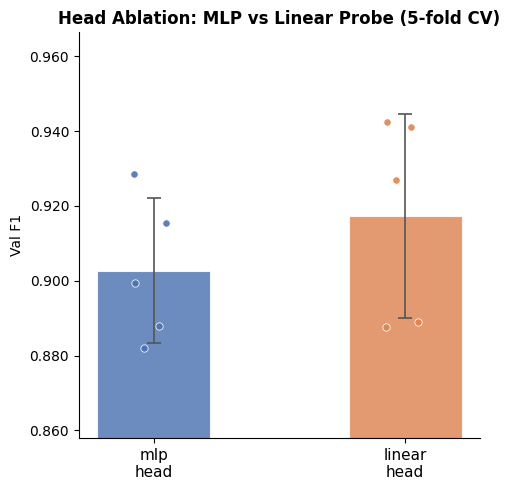

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
colours = {"mlp": "#4C72B0", "linear": "#DD8452"}
x = np.arange(len(HEAD_TYPES))

means = [summary.loc[summary["head"] == h, "mean_val_f1"].values[0]
         if h in summary["head"].values else 0 for h in HEAD_TYPES]
stds  = [summary.loc[summary["head"] == h, "std_val_f1"].values[0]
         if h in summary["head"].values else 0 for h in HEAD_TYPES]

ax.bar(x, means, yerr=stds, capsize=5, width=0.45,
       color=[colours[h] for h in HEAD_TYPES],
       alpha=0.82, edgecolor="white", linewidth=0.8,
       error_kw=dict(elinewidth=1.2, ecolor="#555", capthick=1.2))

for i, head in enumerate(HEAD_TYPES):
    fold_vals = df_ok.loc[df_ok["head"] == head, "val_f1"].values
    jitter = np.random.default_rng(0).uniform(-0.08, 0.08, size=len(fold_vals))
    ax.scatter(i + jitter, fold_vals, color=colours[head],
               edgecolors="white", linewidths=0.6, s=28, zorder=3, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels([f"{h}\nhead" for h in HEAD_TYPES], fontsize=11)
ax.set_title(f"Head Ablation: MLP vs Linear Probe ({N_SPLITS}-fold CV)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Val F1", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.spines[["top", "right"]].set_visible(False)

all_vals = df_ok["val_f1"].astype(float).values
pad = (all_vals.max() - all_vals.min()) * 0.4 or 0.02
ax.set_ylim(all_vals.min() - pad, all_vals.max() + pad)

plt.tight_layout()
utils.save_fig(fig, RESULTS_DIR, "head_ablation", formats=("svg",))
plt.show()

The error bars (the vertical lines with caps on top of each bar) show the standard deviation of F1 across the 5 folds — so how much the score varied depending on which data was used for validation.
The scattered dots show the individual fold F1 scores — so you can see the actual distribution rather than just a summary statistic.